# 🛡️ **Gatekeeper Model Training (MobileNetV2)**

## **1. Introduction & Motivation**

This notebook details the training and evaluation of a lightweight **MobileNetV2** model designed to serve as a preliminary safeguard (the "Gatekeeper") for the primary Knee Osteoarthritis (KOA) severity prediction backend. 

### **Why is a Gatekeeper Model Necessary?**
Deep learning models trained for specific medical tasks (such as grading KOA severity from X-rays) are highly specialized. If a user inadvertently (or maliciously) uploads an image that is completely unrelated to a knee X-ray (e.g., a photo of a dog, a chest X-ray, or a random landscape), the primary severity prediction model will still attempt to classify it, often outputting a confident but entirely meaningless Kellgren-Lawrence (KL) grade. 

To ensure the integrity and reliability of the diagnostic pipeline, we introduce a **binary classification safeguard** before the image ever reaches the heavier KOA severity model.

### **Objective**
The objective of this Gatekeeper model is to accurately differentiate between two classes:
1. **`knee` (In-Distribution):** Valid knee radiographs suitable for severity analysis.
2. **`not_knee` (Out-of-Distribution):** Any image that is not a knee X-ray (random objects, other medical scans, noise).

### **Why MobileNetV2?**
Since this check must occur for *every* uploaded image before main processing begins, inference speed and computational efficiency are paramount. **MobileNetV2** was selected as the backbone for this task because:
* **Lightweight Architecture:** Its use of depthwise separable convolutions drastically reduces the number of parameters.
* **Fast Inference:** It executes in a fraction of a second, ensuring the user experiences minimal latency during the upload and validation process.
* **Sufficient Feature Extraction:** Despite its small size, it is more than capable of capturing the macroscopic structural differences between a knee X-ray and a non-knee image.

## **2. Notebook Overview**
In this notebook, we will cover:
1. **Data Preparation & Augmentation:** Setting up the binary dataset (`knee` vs `not_knee`) and applying robust augmentations.
2. **Model Architecture:** Loading the pre-trained MobileNetV2 backbone and attaching a custom binary classification head.
3. **Training Strategy:** Executing a fine-tuning process using Binary Cross-Entropy loss.
4. **Evaluation:** Assessing the model's accuracy, precision, and recall to ensure virtually zero false positives (i.e., never allowing a non-knee image to pass through).
5. **Exporting:** Saving the optimized weights for direct integration into the FastAPI backend.


In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

# Ensure reproducibility
tf.random.set_seed(42)
np.random.seed(42)

## 1. Setup Data Paths and Parameters

Update `TRAIN_DIR`, `VAL_DIR`, and `TEST_DIR` to point at your dataset.
Set `OOD_THRESHOLD` here; it will be tuned automatically after training
but you can override it for FastAPI deployment.

In [44]:
import shutil, random

BASE_DIR  = r"C:\Users\60122\OneDrive\Desktop\fyp_experiment\Final_year_project\ml_workflow\data\Gate_Keep"
TRAIN_DIR = "/workspaces/gate_keep/FinalYearProject/ml_workflow/data/Gate_Keep/train"
VAL_DIR   = "/workspaces/gate_keep/FinalYearProject/ml_workflow/data/Gate_Keep/validation"
TEST_DIR  = os.path.join(BASE_DIR, "test")

assert os.path.exists(TRAIN_DIR), f"TRAIN_DIR not found: {TRAIN_DIR}"
assert os.path.exists(VAL_DIR),   f"VAL_DIR not found: {VAL_DIR}"

IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS        = 50
TEST_SPLIT    = 0.20   # fraction of training images moved to test

# Deployment threshold — overwritten by ROC optimisation below
OOD_THRESHOLD = 0.5


### 1a. Auto-create Test Split (runs only if TEST_DIR is missing)

Moves `TEST_SPLIT` (default 20 %) of each class from `TRAIN_DIR` into `TEST_DIR`.
Images are chosen **randomly but reproducibly** (seed 42).
Run this once — subsequent runs detect the folder already exists and skip.

> **Important:** the split happens *before* any training so there is zero data leakage.

In [45]:
if not os.path.exists(TEST_DIR):
    print(f"TEST_DIR not found. Carving {TEST_SPLIT*100:.0f}% of TRAIN_DIR into TEST_DIR …")
    random.seed(42)

    for class_name in os.listdir(TRAIN_DIR):
        src_class_dir  = os.path.join(TRAIN_DIR, class_name)
        dst_class_dir  = os.path.join(TEST_DIR,  class_name)

        if not os.path.isdir(src_class_dir):
            continue

        all_files = [
            f for f in os.listdir(src_class_dir)
            if os.path.isfile(os.path.join(src_class_dir, f))
        ]
        n_test = max(1, int(len(all_files) * TEST_SPLIT))
        test_files = random.sample(all_files, n_test)

        os.makedirs(dst_class_dir, exist_ok=True)
        for fname in test_files:
            shutil.move(
                os.path.join(src_class_dir, fname),
                os.path.join(dst_class_dir, fname)
            )
        print(f"  {class_name}: moved {n_test}/{len(all_files)} images → TEST_DIR")

    print("Done. TEST_DIR created:", TEST_DIR)
else:
    print(f"TEST_DIR already exists ({TEST_DIR}). Skipping split.")

# Confirm all three directories are now present
assert os.path.exists(TEST_DIR), f"TEST_DIR still missing after auto-split: {TEST_DIR}"
print("\nDirectory check passed ✓")


TEST_DIR not found. Carving 20% of TRAIN_DIR into TEST_DIR …
  knee: moved 169/845 images → TEST_DIR
  not_knee: moved 359/1796 images → TEST_DIR
Done. TEST_DIR created: C:\Users\60122\OneDrive\Desktop\fyp_experiment\Final_year_project\ml_workflow\data\Gate_Keep/test

Directory check passed ✓


## 2. Data Augmentation and Generators
We use `ImageDataGenerator` for on-the-fly augmentation as confirmed during EDA.

In [46]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',  # Binary classification
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 2113 images belonging to 2 classes.


Found 100 images belonging to 2 classes.


## 3. Calculate Class Weights
Using the training generator's inferred classes, we calculate the `class_weight_dict` automatically to penalize the model heavily for minority class mistakes.

In [47]:
class_labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)
weight_dict = dict(enumerate(class_weights))

print("Class Indices mapping:", train_generator.class_indices)
print("Computed Class Weights:", weight_dict)

Class Indices mapping: {'knee': 0, 'not_knee': 1}
Computed Class Weights: {0: 1.5628698224852071, 1: 0.7352122477383438}


## 4. Build the MobileNetV2 Model
Phase 1: freeze the entire base and train only the head.
Phase 2 (below): unfreeze the last 30 layers for fine-tuning.

In [48]:
def build_model():
    base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")

    # Phase 1 — freeze base for initial transfer learning
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)
    predictions = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

model, base_model = build_model()
model.summary()


Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_4[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']      

## 5. Callbacks & Training

In [49]:
# Save the best model during training
checkpoint = ModelCheckpoint('gatekeeper_best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)

# Stop early if validation loss doesn't improve
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Reduce learning rate when plateauing
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

callbacks = [checkpoint, early_stop, reduce_lr]

### Phase 1 Training (frozen base)

In [50]:
# ── Callbacks (shared across both phases) ──────────────────────────
# Use .keras format — .h5 is legacy
checkpoint = ModelCheckpoint(
    "gatekeeper_best.keras", monitor="val_loss", save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=3, min_lr=1e-6, verbose=1
)
callbacks = [checkpoint, early_stop, reduce_lr]

# ── Phase 1 fit ─────────────────────────────────────────────────────
history_p1 = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),   # was hardcoded 702
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=weight_dict,
    callbacks=callbacks
)


Epoch 1/50
 1/67 [..............................] - ETA: 5:23 - loss: 0.7622 - accuracy: 0.5625

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


50/67 [=====================>........] - ETA: 5s - loss: 0.1609 - accuracy: 0.9425

W0000 00:00:1780995024.655772   30841 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995024.655977   30841 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995024.656129   30841 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995024.656246   30841 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995024.656404   30841 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995024.656638   30841 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995024.656792   30841 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995024.656995   30841 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995024.657231   30841 gp

67/67 [==============================] - ETA: 0s - loss: 0.1263 - accuracy: 0.9565
Epoch 1: val_loss improved from inf to 0.00823, saving model to gatekeeper_best.keras
67/67 [==============================] - 30s 375ms/step - loss: 0.1263 - accuracy: 0.9565 - val_loss: 0.0082 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 2/50
55/67 [=======================>......] - ETA: 4s - loss: 0.0121 - accuracy: 0.9994

W0000 00:00:1780995053.507346   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995053.507636   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995053.507801   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995053.507994   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995053.508296   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995053.508495   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995053.508658   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995053.508861   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780995053.509102   30844 gp

67/67 [==============================] - ETA: 0s - loss: 0.0118 - accuracy: 0.9995
Epoch 2: val_loss improved from 0.00823 to 0.00376, saving model to gatekeeper_best.keras
67/67 [==============================] - 26s 385ms/step - loss: 0.0118 - accuracy: 0.9995 - val_loss: 0.0038 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 3/50
67/67 [==============================] - ETA: 0s - loss: 0.0067 - accuracy: 1.0000
Epoch 3: val_loss improved from 0.00376 to 0.00208, saving model to gatekeeper_best.keras
67/67 [==============================] - 24s 362ms/step - loss: 0.0067 - accuracy: 1.0000 - val_loss: 0.0021 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 4/50
67/67 [==============================] - ETA: 0s - loss: 0.0050 - accuracy: 0.9995
Epoch 4: val_loss improved from 0.00208 to 0.00142, saving model to gatekeeper_best.keras
67/67 [==============================] - 24s 369ms/step - loss: 0.0050 - accuracy: 0.9995 - val_loss: 0.0014 - val_accuracy: 1.0000 - lr: 0.0010
Epoch 5/50
67/67 [======

### Phase 2 Fine-tuning (unfreeze last 30 layers)
Unfreeze the top layers of the MobileNetV2 base and continue training with a 10× lower learning rate.
This adapts the high-level features to the X-ray domain, which differs significantly from ImageNet.

In [51]:
# Unfreeze last 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # 10x lower than Phase 1
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# New checkpoint for Phase 2
checkpoint_p2 = ModelCheckpoint(
    "gatekeeper_best_p2.keras", monitor="val_loss", save_best_only=True, verbose=1
)
early_stop_p2 = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
)
reduce_lr_p2 = ReduceLROnPlateau(
    monitor="val_loss", factor=0.2, patience=3, min_lr=1e-7, verbose=1
)

history_p2 = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=val_generator,
    epochs=20,
    class_weight=weight_dict,
    callbacks=[checkpoint_p2, early_stop_p2, reduce_lr_p2]
)


Epoch 1/20


W0000 00:00:1780996242.046061   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996242.067322   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996242.101538   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996242.116647   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996242.131749   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996242.147358   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996242.182194   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996242.184146   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996242.185435   30839 gp

 1/67 [..............................] - ETA: 7:40 - loss: 1.0157 - accuracy: 0.6875

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1780996243.266892   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996243.267480   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996243.268016   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996243.268583   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996243.269407   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996243.270409   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996243.271990   30844 gpu_timer.cc:114] Skipping

 3/67 [>.............................] - ETA: 16s - loss: 0.5128 - accuracy: 0.8438

...

67/67 [==============================] - ETA: 0s - loss: 0.0044 - accuracy: 0.9991
Epoch 6: val_loss improved from 0.00000 to 0.00000, saving model to gatekeeper_best_p2.keras
67/67 [==============================] - 25s 375ms/step - loss: 0.0044 - accuracy: 0.9991 - val_loss: 3.1853e-08 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 7/20
25/67 [==========>...................] - ETA: 16s - loss: 0.0014 - accuracy: 1.0000

W0000 00:00:1780996399.135124   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996399.135383   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996399.135560   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996399.135797   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996399.135960   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996399.136186   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996399.136528   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996399.136714   30839 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996399.136939   30839 gp

67/67 [==============================] - ETA: 0s - loss: 9.7156e-04 - accuracy: 1.0000
Epoch 7: val_loss did not improve from 0.00000

Epoch 7: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
67/67 [==============================] - 24s 350ms/step - loss: 9.7156e-04 - accuracy: 1.0000 - val_loss: 4.2827e-07 - val_accuracy: 1.0000 - lr: 1.0000e-04
Epoch 8/20
21/67 [========>.....................] - ETA: 16s - loss: 3.6100e-04 - accuracy: 1.0000

W0000 00:00:1780996420.845275   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996420.845574   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996420.845756   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996420.845882   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996420.846052   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996420.846231   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996420.846372   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996420.846530   30844 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996420.846734   30844 gp

67/67 [==============================] - ETA: 0s - loss: 8.1798e-04 - accuracy: 1.0000
Epoch 8: val_loss did not improve from 0.00000
67/67 [==============================] - 25s 373ms/step - loss: 8.1798e-04 - accuracy: 1.0000 - val_loss: 8.4205e-07 - val_accuracy: 1.0000 - lr: 2.0000e-05
Epoch 9/20
67/67 [==============================] - ETA: 0s - loss: 5.0501e-04 - accuracy: 1.0000
Epoch 9: val_loss did not improve from 0.00000
67/67 [==============================] - 23s 338ms/step - loss: 5.0501e-04 - accuracy: 1.0000 - val_loss: 1.7452e-06 - val_accuracy: 1.0000 - lr: 2.0000e-05
Epoch 10/20
67/67 [==============================] - ETA: 0s - loss: 4.9975e-04 - accuracy: 1.0000
Epoch 10: val_loss did not improve from 0.00000

Epoch 10: ReduceLROnPlateau reducing learning rate to 3.999999898951501e-06.
67/67 [==============================] - 23s 340ms/step - loss: 4.9975e-04 - accuracy: 1.0000 - val_loss: 2.9702e-06 - val_accuracy: 1.0000 - lr: 2.0000e-05
Epoch 11/20
67/67 [======

## 6. Plot Training History

## 6. Plot Training History (both phases)

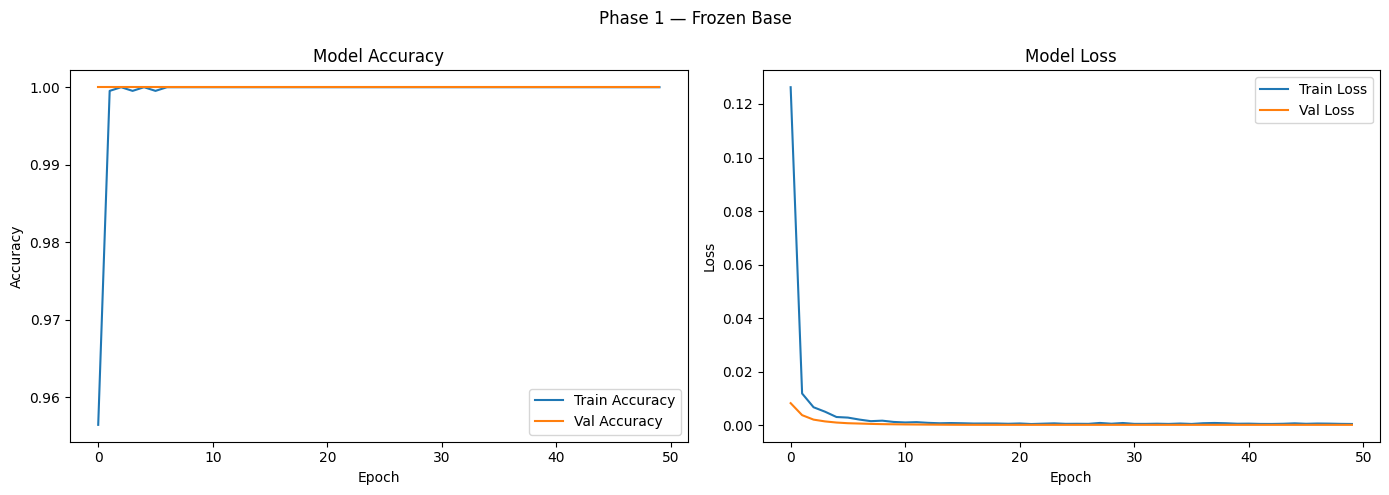

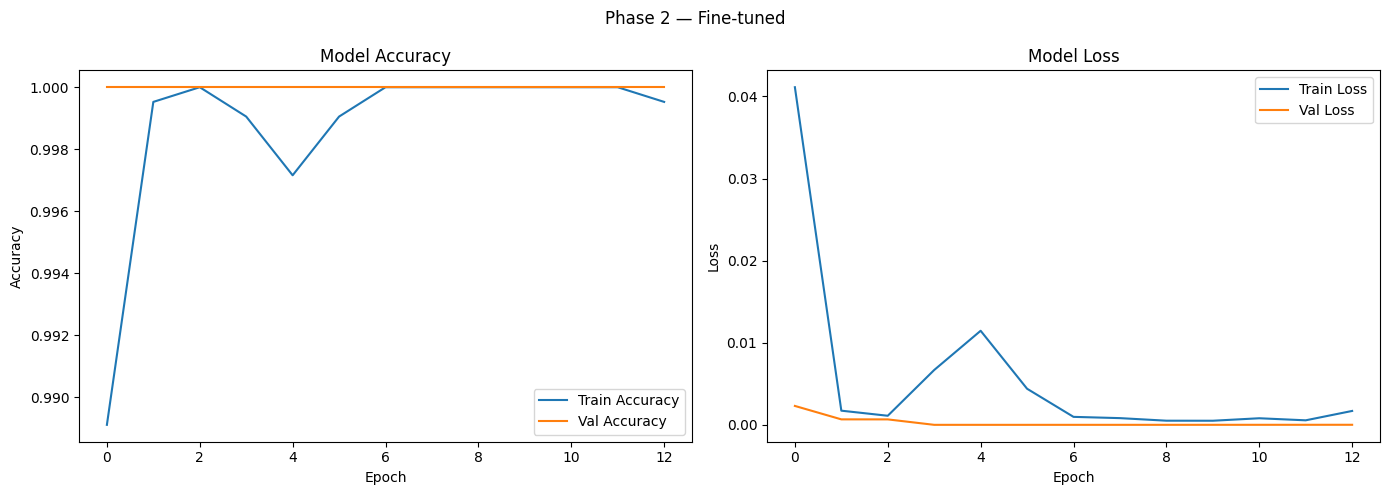

In [52]:
def plot_history(history, title=""):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title)

    ax[0].plot(history.history["accuracy"],     label="Train Accuracy")
    ax[0].plot(history.history["val_accuracy"], label="Val Accuracy")
    ax[0].set_title("Model Accuracy")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].legend()

    ax[1].plot(history.history["loss"],     label="Train Loss")
    ax[1].plot(history.history["val_loss"], label="Val Loss")
    ax[1].set_title("Model Loss")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_p1, title="Phase 1 — Frozen Base")
plot_history(history_p2, title="Phase 2 — Fine-tuned")


## 7. Save Final Model for FastAPI
The model checkpointing automatically saves the best weights, but we explicitly save the final compiled architecture below. This `.h5` model can be loaded in the FastAPI server using `tensorflow.keras.models.load_model('Gatekeeper_MobileNetV2.h5')`.

Saved in native Keras format (`.keras`) which is recommended for TF2/Keras 3.
Load in FastAPI with:
```python
from tensorflow.keras.models import load_model
gatekeeper = load_model('Gatekeeper_MobileNetV2.keras')
```

In [53]:
model.save('Gatekeeper_MobileNetV2.keras')
print('Model saved as Gatekeeper_MobileNetV2.keras')


Model saved as Gatekeeper_MobileNetV2.keras


## 8. Detailed Evaluation (Validation & Test Sets)
Here we will evaluate the model thoroughly on the validation set. If you have a separate test set, you can point `TEST_DIR` to it and run the same logic.

## 8. Detailed Evaluation
The evaluation function now returns the **optimal threshold** derived from the ROC curve
(maximises TPR-FPR Youden J statistic). Use this threshold — not 0.5 — in FastAPI.

In [54]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
import seaborn as sns

def evaluate_model_performance(model, generator, title="Validation"):
    print(f"\n{"="*50}")
    print(f"Evaluating on {title} Set...")
    print(f"{"="*50}")

    generator.reset()
    y_true       = generator.classes
    y_pred_probs = model.predict(generator, verbose=1)

    # ── Optimal threshold from ROC curve (Youden J) ─────────────────
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    optimal_idx       = int(np.argmax(tpr - fpr))
    optimal_threshold = float(thresholds[optimal_idx])
    print(f"\nOptimal classification threshold (Youden J): {optimal_threshold:.4f}")

    y_pred_labels = (y_pred_probs > optimal_threshold).astype(int).reshape(-1)

    acc     = accuracy_score(y_true, y_pred_labels)
    bal_acc = balanced_accuracy_score(y_true, y_pred_labels)
    roc_auc = roc_auc_score(y_true, y_pred_probs)

    print(f"\nOverall Accuracy : {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"ROC AUC Score    : {roc_auc:.4f}\n")

    class_names = list(generator.class_indices.keys())
    print("Classification Report:")
    print(classification_report(y_true, y_pred_labels, target_names=class_names))

    # ── Low-confidence band analysis ─────────────────────────────────
    low_conf_mask = (
        (y_pred_probs.reshape(-1) > 0.3) & (y_pred_probs.reshape(-1) < 0.7)
    )
    print(f"Low-confidence predictions (0.3–0.7): {low_conf_mask.sum()} / {len(y_pred_probs)}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cm_matrix = confusion_matrix(y_true, y_pred_labels)
    sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title(f"Confusion Matrix ({title})")
    axes[0].set_ylabel("True Label")
    axes[0].set_xlabel("Predicted Label")

    axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=2, label="Random")
    axes[1].scatter(fpr[optimal_idx], tpr[optimal_idx], s=80, color="red",
                    zorder=5, label=f"Optimal thresh = {optimal_threshold:.3f}")
    axes[1].set_title(f"ROC Curve ({title})")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    return acc, bal_acc, roc_auc, optimal_threshold


### Run Evaluation on Validation Data
Since we only defined `val_generator`, let's run the evaluation on it. The validation generator has `shuffle=False` which is critical for correctly matching predictions to true labels.

### Run Evaluation on Validation Data


Evaluating on Validation Set...
4/4 [==============================] - 1s 114ms/step

Optimal classification threshold (Youden J): 1.0000

Overall Accuracy : 0.9900
Balanced Accuracy: 0.9900
ROC AUC Score    : 1.0000

Classification Report:
              precision    recall  f1-score   support

        knee       0.98      1.00      0.99        50
    not_knee       1.00      0.98      0.99        50

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100

Low-confidence predictions (0.3–0.7): 0 / 100


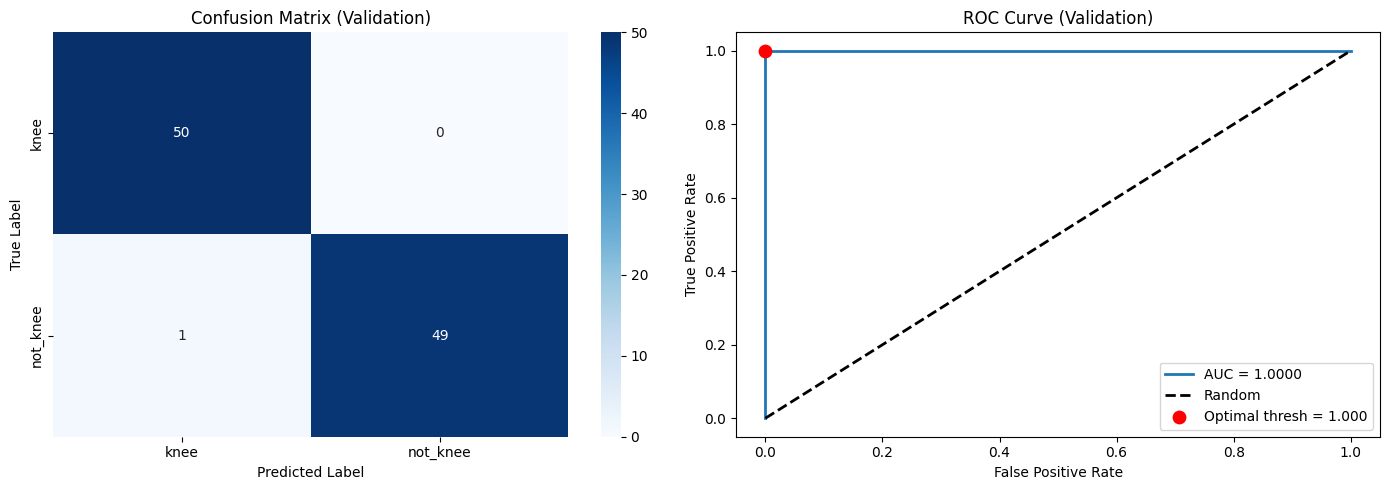


>>> OOD_THRESHOLD to use in FastAPI: 1.0000


In [55]:
try:
    model.load_weights("gatekeeper_best_p2.keras")
except Exception:
    print("Could not load Phase-2 best weights. Using current weights.")

val_acc, val_bal_acc, val_auc, OOD_THRESHOLD = evaluate_model_performance(
    model, val_generator, title="Validation"
)
print(f"\n>>> OOD_THRESHOLD to use in FastAPI: {OOD_THRESHOLD:.4f}")


### Run Evaluation on Test Data

Found 528 images belonging to 2 classes.

Evaluating on Test Set...
17/17 [==============================] - 3s 146ms/step

Optimal classification threshold (Youden J): 0.9997

Overall Accuracy : 0.9981
Balanced Accuracy: 0.9986
ROC AUC Score    : 1.0000

Classification Report:
              precision    recall  f1-score   support

        knee       0.99      1.00      1.00       169
    not_knee       1.00      1.00      1.00       359

    accuracy                           1.00       528
   macro avg       1.00      1.00      1.00       528
weighted avg       1.00      1.00      1.00       528

Low-confidence predictions (0.3–0.7): 0 / 528


W0000 00:00:1780996572.853833   30842 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996572.854380   30842 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996572.854693   30842 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996572.855106   30842 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996572.855513   30842 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996572.855985   30842 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996572.856671   30842 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996572.857528   30842 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1780996572.858308   30842 gp

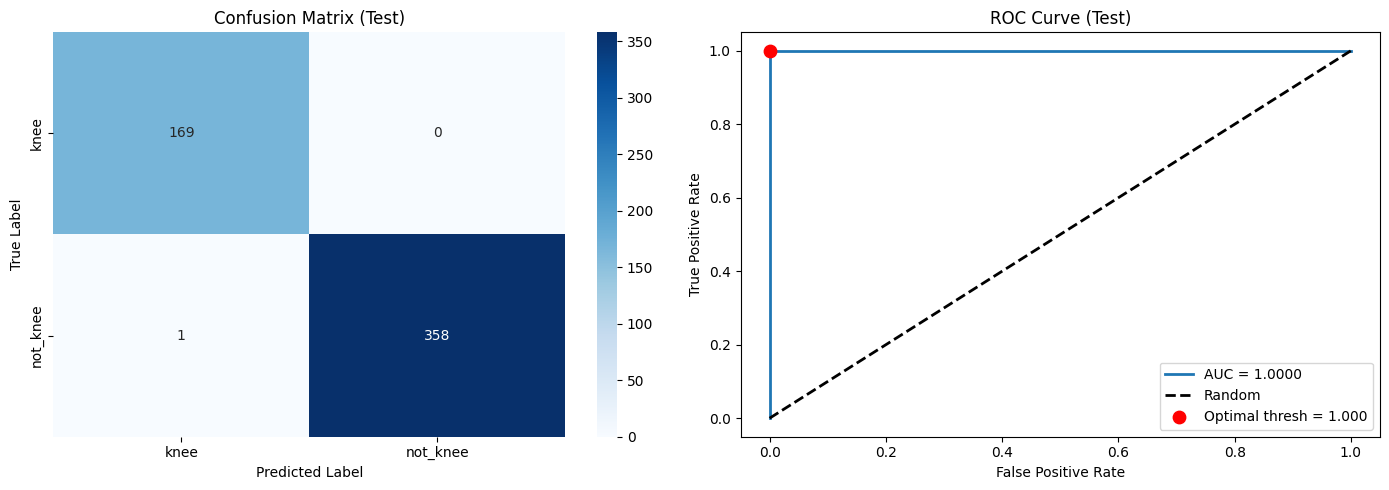

In [56]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)
test_acc, test_bal_acc, test_auc, _ = evaluate_model_performance(
    model, test_generator, title="Test"
)
